In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df = pd.read_parquet(
    r"../data/processed/v6/housing_residential_processed.parquet"
).copy()
df_primary = df[df["market_type"] == "primary"]
df_secondary = df[df["market_type"] == "secondary"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336403 entries, 0 to 1336402
Data columns (total 23 columns):
 #   Column                                          Non-Null Count    Dtype         
---  ------                                          --------------    -----         
 0   address                                         1336403 non-null  string        
 1   longitude                                       1336403 non-null  float64       
 2   latitude                                        1336403 non-null  float64       
 3   area                                            1336403 non-null  float64       
 4   room_count                                      1190602 non-null  Int64         
 5   floor                                           1336403 non-null  Int64         
 6   floor_count                                     126801 non-null   Int64         
 7   market_type                                     1336403 non-null  string        
 8   flat_type             

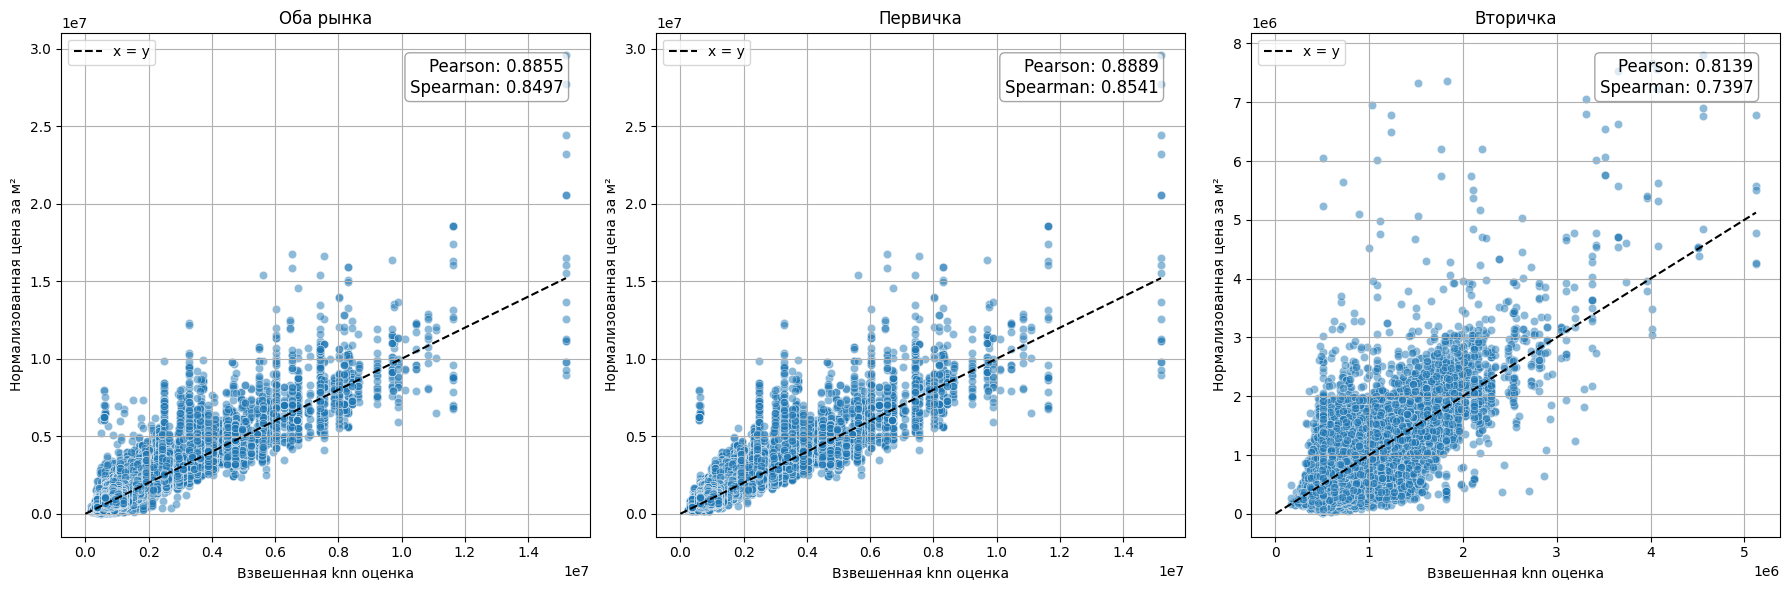

In [99]:
corr_p = {'Оба рынка': df[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr().iloc[0,1],
          'Первичка': df_primary[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr().iloc[0,1],
          'Вторичка': df_secondary[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr().iloc[0,1]}
corr_s = {'Оба рынка': df[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr(method='spearman').iloc[0,1],
          'Первичка': df_primary[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr(method='spearman').iloc[0,1],
          'Вторичка': df_secondary[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr(method='spearman').iloc[0,1]}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dfs = [(df,  'Оба рынка'), (df_primary,   'Первичка'), (df_secondary, 'Вторичка')]

for ax, (data, title) in zip(axes, dfs):
    sns.scatterplot(data=data,
        x='knn_weighted_price_per_square_meter_normalized', y='price_per_square_meter_normalized',
        alpha=0.5, ax=ax)

    max_val = data['knn_weighted_price_per_square_meter_normalized'].max()
    ax.plot([0, max_val], [0, max_val], 'k--', label='x = y')
    ax.set_xlabel('Взвешенная knn оценка')
    ax.set_ylabel('Нормализованная цена за м²')
    ax.set_title(title)

    text = f"Pearson: {corr_p[title]:.4f}\nSpearman: {corr_s[title]:.4f}"
    ax.text(0.95, 0.95, text,
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray'))
    
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

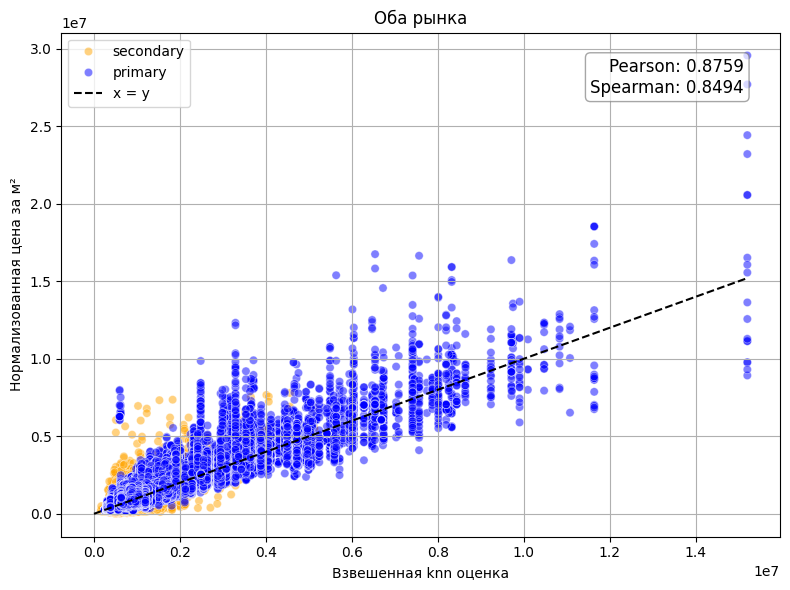

In [96]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(data=df,
    x='knn_weighted_price_per_square_meter_normalized', y='price_per_square_meter_normalized',
    hue='market_type', palette={'primary': 'blue', 'secondary': 'orange'},
    alpha=0.5, ax=ax)

max_val = df['knn_weighted_price_per_square_meter_normalized'].max()
ax.plot([0, max_val], [0, max_val], 'k--', label='x = y')

ax.set_xlabel('Взвешенная knn оценка')
ax.set_ylabel('Нормализованная цена за м²')
ax.set_title('Оба рынка')
ax.legend()
ax.grid(True)

ax.text(0.95, 0.95, f'Pearson: {corr_p["Оба рынка"]:.4f}\nSpearman: {corr_s["Оба рынка"]:.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.show()

Обрежем цену до 6млн за м^2

In [86]:
df_ = df[df['price_per_square_meter_normalized'] <= 0.6*1e7]
df_primary_ = df_[df_["market_type"] == "primary"]
df_secondary_ = df_[df_["market_type"] == "secondary"]

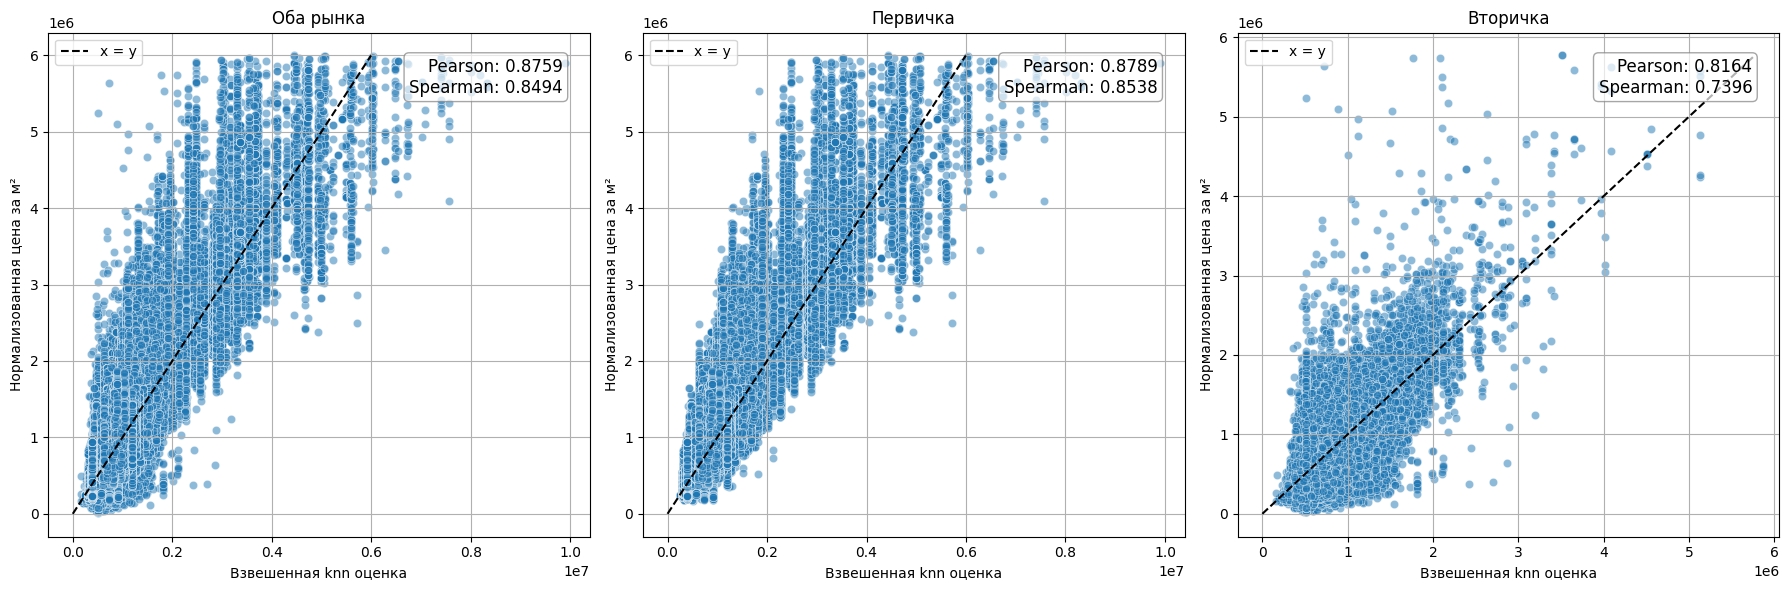

In [100]:
corr_p = {'Оба рынка': df_[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr().iloc[0,1],
          'Первичка': df_primary_[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr().iloc[0,1],
          'Вторичка': df_secondary_[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr().iloc[0,1]}
corr_s = {'Оба рынка': df_[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr(method='spearman').iloc[0,1],
          'Первичка': df_primary_[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr(method='spearman').iloc[0,1],
          'Вторичка': df_secondary_[['price_per_square_meter_normalized', 'knn_weighted_price_per_square_meter_normalized']].corr(method='spearman').iloc[0,1]}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dfs = [(df_,  'Оба рынка'), (df_primary_,   'Первичка'), (df_secondary_, 'Вторичка')]

for ax, (data, title) in zip(axes, dfs):
    sns.scatterplot(data=data,
        x='knn_weighted_price_per_square_meter_normalized', y='price_per_square_meter_normalized',
        alpha=0.5, ax=ax)

    max_val = data['price_per_square_meter_normalized'].max()
    ax.plot([0, max_val], [0, max_val], 'k--', label='x = y')
    ax.set_xlabel('Взвешенная knn оценка')
    ax.set_ylabel('Нормализованная цена за м²')
    ax.set_title(title)

    text = f"Pearson: {corr_p[title]:.4f}\nSpearman: {corr_s[title]:.4f}"
    ax.text(0.95, 0.95, text,
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray'))
    
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

C:\Users\savely\AppData\Local\Temp\ipykernel_17352\1082942449.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\savely\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


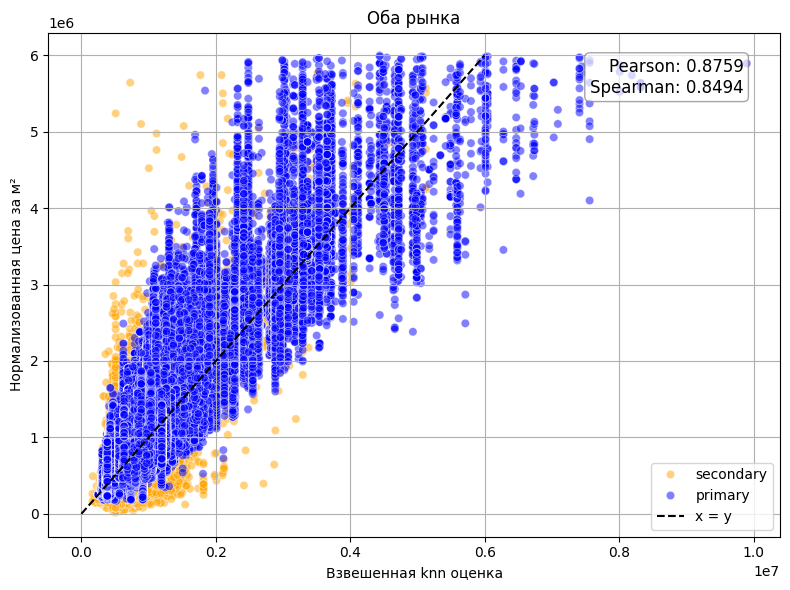

In [97]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(data=df_,
    x='knn_weighted_price_per_square_meter_normalized', y='price_per_square_meter_normalized',
    hue='market_type', palette={'primary': 'blue', 'secondary': 'orange'},
    alpha=0.5, ax=ax)

max_val = df_['price_per_square_meter_normalized'].max()
ax.plot([0, max_val], [0, max_val], 'k--', label='x = y')

ax.set_xlabel('Взвешенная knn оценка')
ax.set_ylabel('Нормализованная цена за м²')
ax.set_title('Оба рынка')
ax.legend()
ax.grid(True)

ax.text(0.95, 0.95, f'Pearson: {corr_p["Оба рынка"]:.4f}\nSpearman: {corr_s["Оба рынка"]:.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.show()